### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata
import scipy
import seaborn as sns
from matplotlib.pyplot import figure
from sklearn.preprocessing import MinMaxScaler
import scvi
from scvi.distributions import NegativeBinomial
import torch
from simulate_gene_expression import *

np.random.seed(0)
torch.manual_seed(0)

/home/ajita/anaconda3/envs/cell2loc/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/ajita/anaconda3/envs/cell2loc/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


### Path

In [2]:
"""
Guidelines:
scale_factor: user defined hyper-paramters, by default = 10000,
Large dataset (SlideseqV2/VisiumHD: no of cells >= 20000):100

All dataset scale_factor = 10000, except the following:
Prostate Cancer, Hippocampus, Cerebellum, Kidney Human6 = 100
Lung cancer Visium HD and Kidney Human1 = 1000
No sampling from muti-variate Gaussian is performed for VisiumHD datasets due to memory constraints (original umi counts used).
i.e. sample_UMI() function is skipped and original_umi_counts to be passed in place of sampled_umi in scale_adata function()

For certain dataset, Average_SynthST_ReX_Norm is used in place of Average_SynthST_ReX
"""

'\nGuidelines:\nscale_factor: user defined hyper-paramters, by default = 10000,\nLarge dataset (SlideseqV2/VisiumHD: no of cells >= 20000):100\n\nAll dataset scale_factor=10000, except the following:\nProstate Cancer, Hippocampus, Cerebellum, Kidney Human6 = 100\nLung cancer Visium HD and Kidney Human1 = 1000\nNo sampling from muti-variate Gaussian is performed for VisiumHD datasets due to memory constraints (original umi counts used).\n\nFor certain dataset, Average_STAGATE_ReX_Norm is used in place of Average_STAGATE_ReX\n'

In [3]:


dataset_name = "Breast Cancer ER+"
cell_type_col = "celltype_minor"
scale_factor = 10000
simulator_column = "Average_STAGATE_ReX"

cell2loc_st = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Cancer/deconvolution_outputs/ER+/cell2location_map/st.h5ad"

signature_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Cancer/deconvolution_outputs\
/ER+/reference_signatures/sc_breast_cancer.h5ad"

st_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Cancer/ST/ER+_CID4290_ST.h5ad"
simulated_data_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/Breast_Cancer/simulator_outputs/ER+_CID4290/"

sim_adata = sc.read_h5ad(simulated_data_path + "simulated_st.h5ad")
ctp_var_names = sim_adata.var_names


In [4]:
# ST Output of Cell2location
sam = sc.read_h5ad(cell2loc_st)
ctps = sam.obsm["q05_cell_abundance_w_sf"].sum(axis = 1)
dt_N = pd.DataFrame({"spot_id" : ctps.index, "sum" : ctps.values})
m_g = sam.uns["mod"]["post_sample_means"]["m_g"][0]
#N_s  = sam.uns["mod"]["post_sample_means"]["n_s_cells_per_location"]
print ("m_g", m_g)

# Output of SynthST
dt_N[dt_N["spot_id"].isin(sim_adata.obs_names)]
N_cell2loc = np.ceil(dt_N[dt_N.columns[1:]].sum(axis = 1))
#print (np.min(N_cell2loc), np.max(N_cell2loc))
obs_names = sim_adata.obs_names
decon_matrix = sim_adata.obsm[simulator_column] 
spot_barcodes = sim_adata.obs_names
num_spots = len(decon_matrix)
num_celltypes = decon_matrix.shape[1]

# Original Spatial dataset
original_st_data = sc.read_h5ad(st_path)
original_st_data = original_st_data[original_st_data.obs_names.isin(spot_barcodes), :]

cov_matrix = np.zeros((num_spots,num_spots))
tissue_positions_list = original_st_data.obsm["spatial"]

# Single cell data signature
ann = sc.read_h5ad(signature_path)
ann = ann[:, ann.var_names.isin(sam.var_names)]



[2.6386786  0.6474676  0.39352474 ... 1.20772    1.6645942  1.4677882 ]
3.0 68.0


### Generating Simulated datasets

Generating simulated gene expression data
(34541, 11854)
(11854, 22)


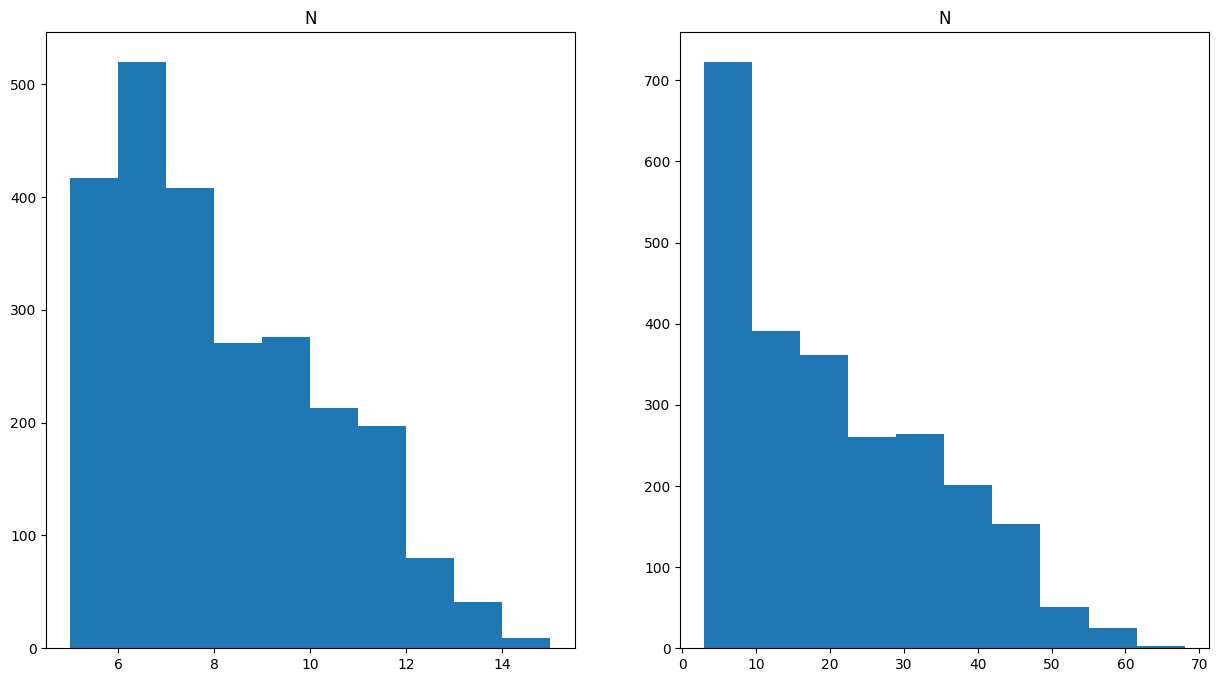

In [5]:
# scaled no of cells in each spot between 5-15.
cells_at_spot = plot_histogram(N_cell2loc)
#cells_at_spot.to_csv(simulated_data_path + "simulated_cells_at_spot.csv")
print ("Generating simulated gene expression data")
adata = generate_expression(ann, sam, original_st_data, decon_matrix, cells_at_spot, ctp_var_names, m_g, spot_barcodes)



### Downsampling the simulated dataset

Compute distance matrix
Sample UMI from Multi-variate Gaussian distribution
0.6372392935666479 1.221417321121371


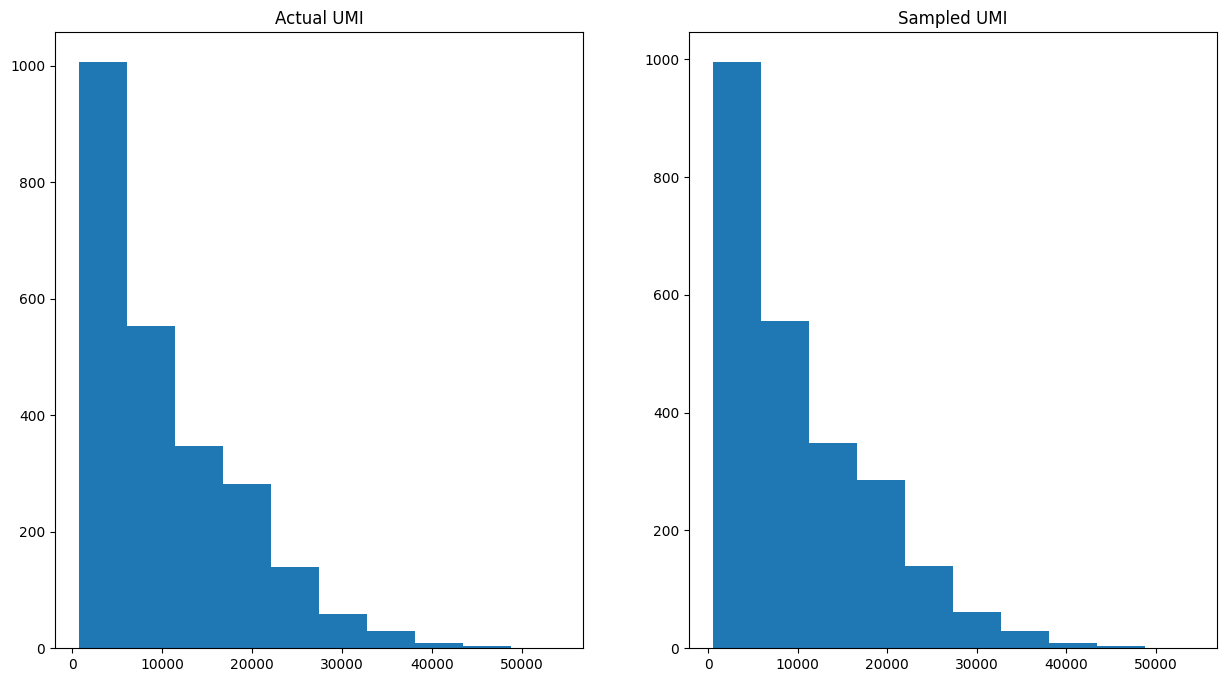

In [6]:
print ("Compute distance matrix")
distance_matrix = compute_distane_matrix(num_spots, tissue_positions_list)

print ("Sample UMI from Multi-variate Gaussian distribution")
sampled_umi, original_umi_counts = sample_UMI(num_spots, distance_matrix, original_st_data, cov_matrix, scale_factor)

Scale Anndata
scaling  0.07586136694541101 2.423918988846124
False


/data/Ajita/Spatial/SIMULATOR_spatial_deconvolution/Simulator_runs/Step2_Simulation/simulate_gene_expression.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  original_st_data.obs['umi_counts_actual'] = original_umi_counts


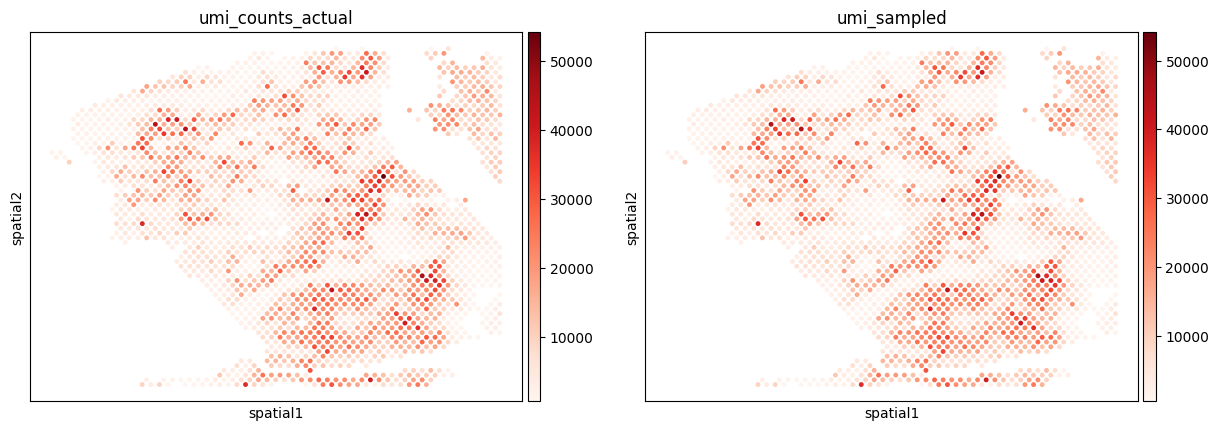

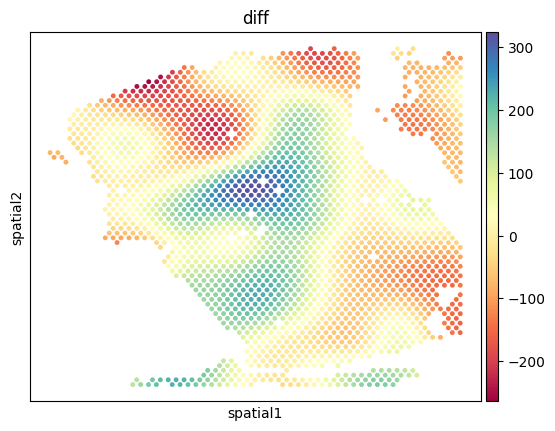

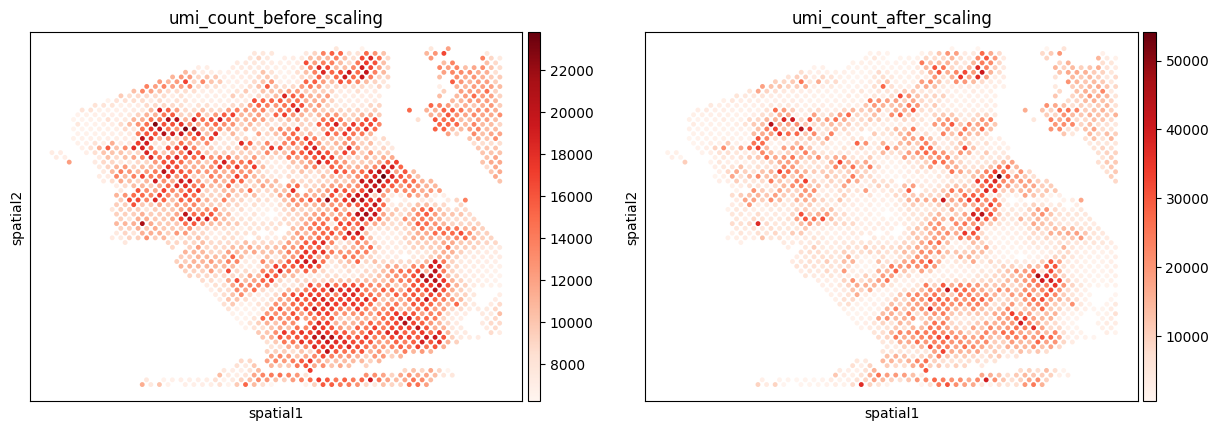

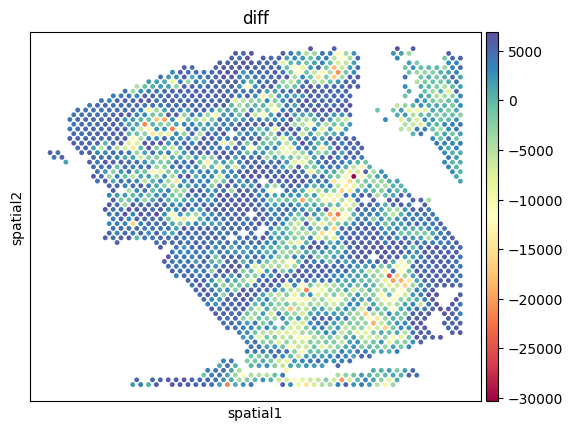

In [7]:
print ("Scale Anndata")
adata = scale_anndata(adata, original_st_data, sampled_umi, original_umi_counts)

In [ ]:
adata.X = np.round(adata.X)
adata.X = adata.X.astype(np.uint64)
print (np.min(adata.X))

In [ ]:
adata.write_h5ad(simulated_data_path + "simulated_gene_expression_average.h5ad")